# 重回帰分析への拡張
このnotebookでは、Bike Sharingデータを用いて、単回帰モデルから重回帰モデルへの拡張を行う。

構成は以下のとおりである。

## 分析の流れ

1. 目的
2. データ読み込み
3. 使用変数の説明
4. 探索的分析
5. 訓練データ・テストデータ分割
6. モデル作成
   - nullモデル
   - 単回帰モデル
   - 2次項あり単回帰モデル
   - 重回帰モデル
7. 訓練データでのモデル比較
8. テストデータでの予測性能評価
9. 残差分析
10. 考察

#### 備考 : 2~4は単回帰分析のnotebookと同じなので、コードのみを載せておく。

# 1. 目的
本notebookでは、Bike Sharingデータを対象に、単回帰モデルから重回帰モデルへ拡張することで、利用者数 `cnt` の予測精度がどの程度改善するかを検証する。
また、各モデルの評価指標や残差分析を通じて、モデルの有効性と限界について考察する。

## ライブラリの読み込み

In [1]:
# ファイルパスの追加
import sys
sys.path.append("../src")

# 前処理を行うための関数
from preprocessing import load_and_clean_data
from preprocessing import print_features

# モデルを構築するための関数
from modeling import fit_multiple_regression
# 回帰モデルを検証するための関数
from modeling import verif_model, scatter_and_model, resid_and_predict
from modeling import mae_rmse_r2, test_pred_resid


# 数値計算に使うライブラリ
import pandas as pd
import numpy as np
from scipy import stats
#表示桁数の設定
pd.set_option('display.precision', 3)
np.set_printoptions(precision=3)
#グラフを描画するライブラリ
from matplotlib import pyplot as plt
import seaborn as sns
#グラフの日本語表記
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = 'Meiryo'
#統計を推定するライブラリ
import statsmodels.formula.api as smf
import statsmodels.api as sm

#テストデータと訓練データに分ける
from sklearn.model_selection import train_test_split

# 2. データの読み込み

In [2]:
file_path = "day.csv"
df = load_and_clean_data(file_path)


読み込んだデータ :

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   

   weathersit   temp  atemp    hum  windspeed  casual  registered   cnt  
0           2  0.344  0.364  0.806      0.160     331         654   985  
1           2  0.363  0.354  0.696      0.249     131         670   801  
2           1  0.196  0.189  0.437      0.248     120        1229  1349  

データの基本情報 :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null 

# 3. 使用変数の選択
## 使用変数

目的変数は、1日あたりのレンタル自転車利用者数を表す `cnt` とする。

説明変数として、気象条件を表す `temp`, `hum`, `windspeed` に加え、
季節性や曜日効果を考慮するために `season`, `weathersit`, `weekday`, `mnth` を用いた。
また、2011年と2012年の水準差を表す変数として `yr` を加えた。

`temp` については、気温が高くなるほど利用者数が単調に増えるとは限らず、
一定以上の気温では利用が減少する可能性があるため、2次項も加えた。

In [3]:
# 説明変数

# 数値型の説明変数
numeric_features = ["temp", "hum", "windspeed"]

# カテゴリー型の説明変数
categorical_features = ['yr', 'mnth', 'season', 'weathersit', 'weekday']

# 2次項を組み込む説明変数
quadratic_features = ["temp"]

# 選択した説明変数の表示
print_features(numeric_features, categorical_features)


説明変数は8個

数値型の説明変数(3個) :
数値型の説明変数
temp
hum
windspeed

カテゴリー型の説明変数(5個)
yr
mnth
season
weathersit
weekday


# 4. 探索的分析
ここでは、重回帰モデルに入れる前の探索的分析として、各数値変数と目的変数の単純な関係を確認する。

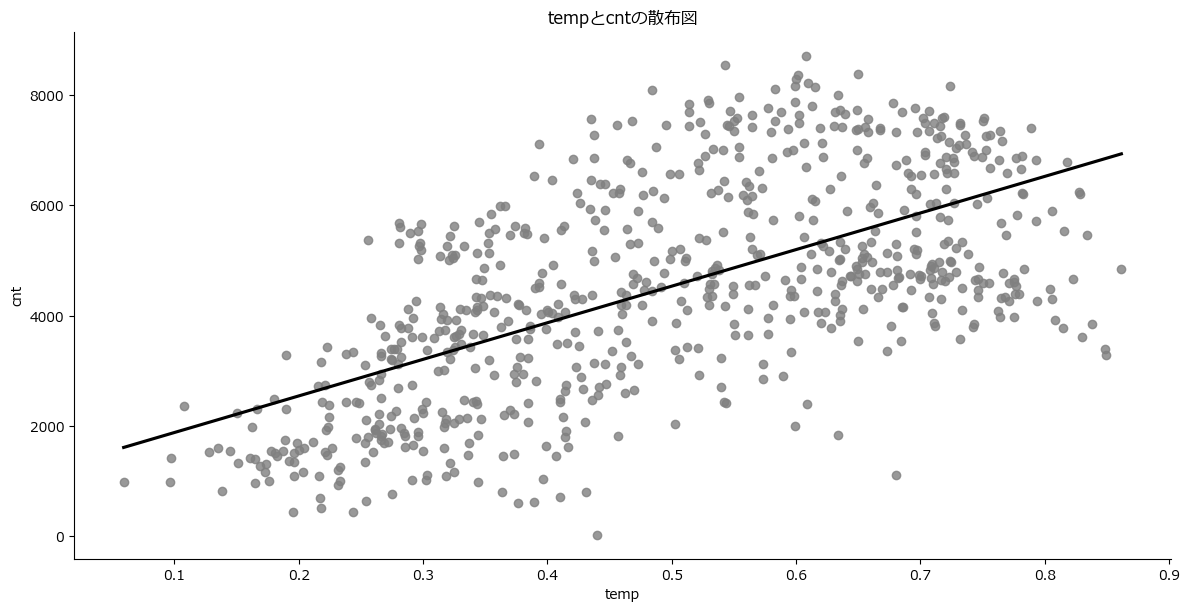

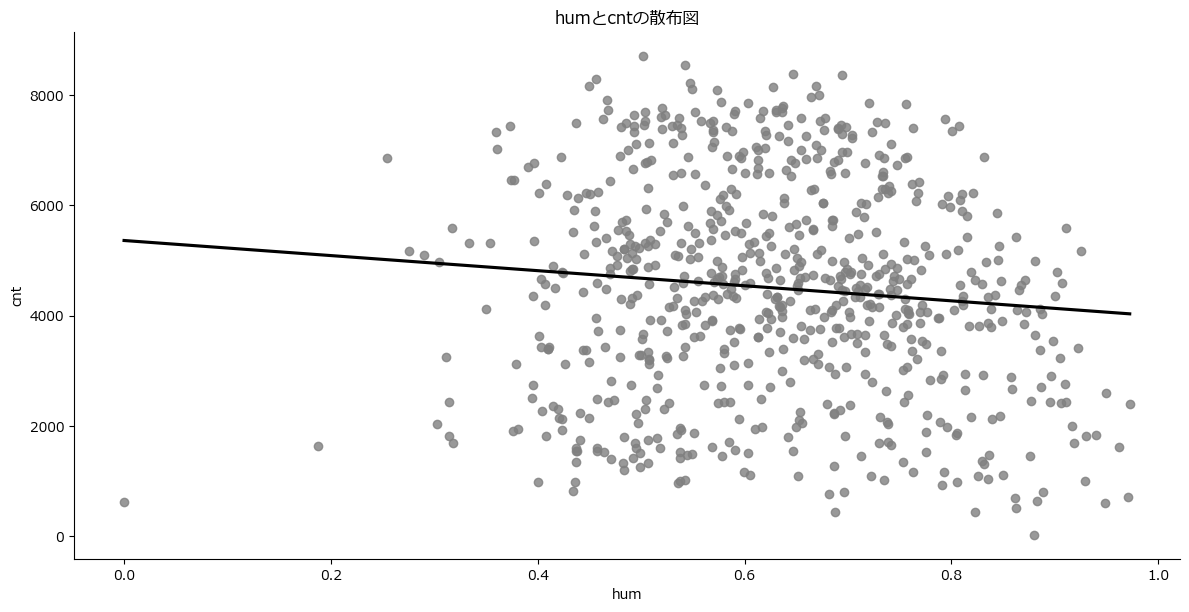

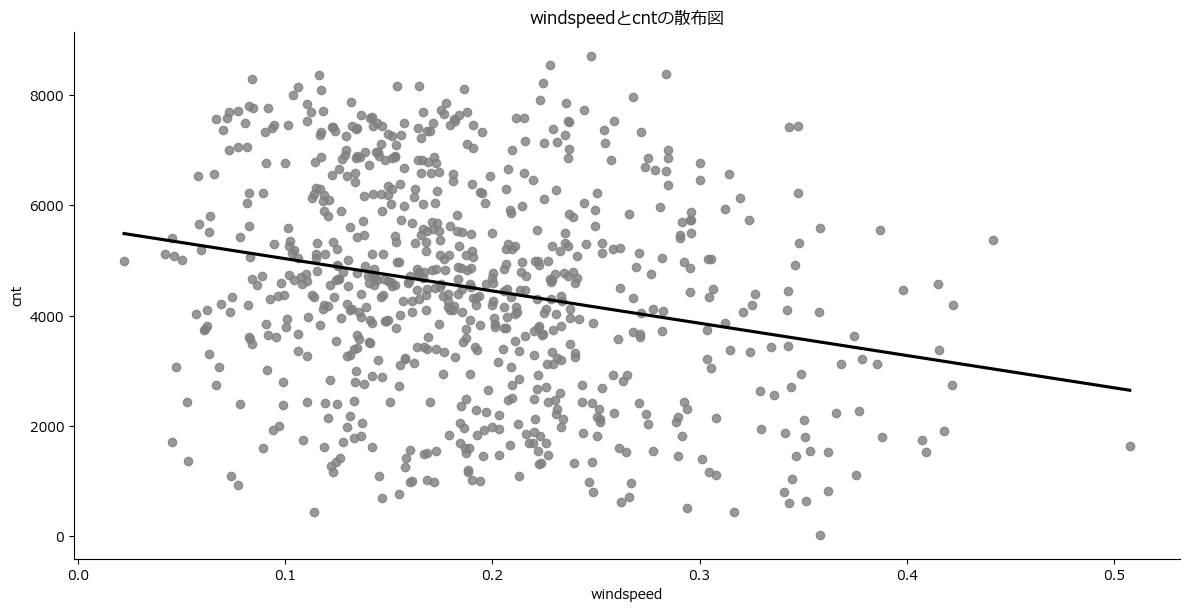

In [4]:
scatter_and_model(data=df, numeric_features=numeric_features, target='cnt')

# 5. 訓練データとテストデータの分割
本データは日別の時系列データであるため、ランダム分割を行うと、将来の情報が訓練データに混入する可能性がある。

そこで本分析では、実運用に近い状況を想定し、前半80%を訓練データ、後半20%をテストデータとした。

これにより、過去のデータから将来の利用者数を予測する性能を評価する。

In [5]:
# 説明変数と目的変数に分ける
train_df = df.iloc[:int(len(df) * 0.8)]
test_df = df.iloc[int(len(df) * 0.8):]

# 6. モデル作成

In [6]:
# nullモデル
null_model = smf.ols('cnt ~ 1', data=train_df).fit()

nullモデルは説明変数を用いず、訓練データにおける目的変数の平均値のみで予測するモデルである。
このモデルを基準として、説明変数を加えることでどの程度予測精度が改善するかを確認する。

In [7]:
# 単回帰モデルの構築
simple_model = fit_multiple_regression(
    df=train_df,
    target='cnt',
    numeric_features=['temp']
)

使用する回帰式:
cnt ~ temp


In [8]:
# 単回帰モデル(2次項あり)
simple2_model = fit_multiple_regression(
    df=train_df,
    target='cnt',
    numeric_features=['temp'],
    quadratic_features=['temp']
)

使用する回帰式:
cnt ~ temp + I(temp ** 2)


In [9]:
# 重回帰モデルの構築
mul_model = fit_multiple_regression(
    df=train_df,
    target='cnt',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    quadratic_features=quadratic_features
)
mul_model.summary()

使用する回帰式:
cnt ~ temp + hum + windspeed + C(yr) + C(mnth) + C(season) + C(weathersit) + C(weekday) + I(temp ** 2)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                     145.0
Date:                Wed, 20 May 2026   Prob (F-statistic):          1.09e-231
Time:                        13:56:59   Log-Likelihood:                -4593.2
No. Observations:                 584   AIC:                             9242.
Df Residuals:                     556   BIC:                             9365.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             39.2335    264.356      0.148      0.882    -480.025     558.492
C(yr)[T.1]          1945.3641     63.793     30.495      0.000    1820.060    2070.668
C(mnth)[T.2]         -77.9561    124.409     -0.627      0.531    -322.325     166.413
C(mnth)[T.3]         292.2832    149.982      1.949      0.052      -2.318     586.884
C(mnth)[T.4]         284.3644    224.989      1.264      0.207    -157.568     726.297
C(mnth)[T.5]         853.5567    241.706      3.531      0.000     378.788    1328.325
C(mnth)[T.6]        1038.0289    258.086      4.022      0.000     531.086    1544.971
C(mnth)[T.7]         891.5759    296.797      3.004      0.003     308.595    1474.557
C(mnth)[T.8]         805.5061    297.683      2.706      0.007     220.785    1390.227
C(mnth)[T.9]         747.4004    276.206      2.706      0.007     204.865    1289.936
C(mnth)[T.10]        347.2463    275.580      1.260      0.208    -194.059     888.552
C(mnth)[T.11]        -60.2217    269.992     -0.223      0.824    -590.550     470.107
C(mnth)[T.12]        114.9051    206.894      0.555      0.579    -291.484     521.294
C(season)[T.2]       694.0026    158.356      4.383      0.000     382.953    1005.052
C(season)[T.3]       821.6645    206.471      3.980      0.000     416.107    1227.222
C(season)[T.4]      1205.1117    203.222      5.930      0.000     805.934    1604.289
C(weathersit)[T.2]  -435.5590     73.181     -5.952      0.000    -579.305    -291.813
C(weathersit)[T.3] -1762.9437    179.361     -9.829      0.000   -2115.251   -1410.637
C(weekday)[T.1]       52.7956     99.876      0.529      0.597    -143.385     248.976
C(weekday)[T.2]      225.2099    100.660      2.237      0.026      27.490     422.929
C(weekday)[T.3]      183.9597    101.016      1.821      0.069     -14.460     382.379
C(weekday)[T.4]      253.4321    100.856      2.513      0.012      55.327     451.538
C(weekday)[T.5]      255.6128    100.824      2.535      0.012      57.571     453.654
C(weekday)[T.6]      286.1764    100.056      2.860      0.004      89.643     482.710
temp                1.457e+04   1169.323     12.456      0.000    1.23e+04    1.69e+04
hum                -1520.6776    264.909     -5.740      0.000   -2041.023   -1000.332
windspeed          -2984.9404    391.896     -7.617      0.000   -3754.718   -2215.163
I(temp ** 2)       -1.192e+04   1211.340     -9.844      0.000   -1.43e+04   -9544.697
==============================================================================
Omnibus:                       48.016   Durbin-Watson:                   1.415
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              140.470
Skew:                          -0.369   Prob(JB):                     3.14e-31
Kurtosis:                       5.287   Cond. No.                     

### 構築したモデルの要点の整理と確認

In [10]:
df_simple_params, df_simple_model = verif_model(simple_model, numeric_features=['temp'], model_name='単回帰モデル')
df_simple2_params, df_simple2_model = verif_model(simple2_model, numeric_features=['temp'], quadratic_features=['temp'], model_name='単回帰モデル(2次項あり)')
df_mul_params, df_mul_model = verif_model(mul_model, numeric_features, categorical_features, quadratic_features, model_name='重回帰モデル')

In [11]:
#係数ごとの出力
df_mul_params

,変数,種類,係数,p値,標準誤差,t値
0,temp,数値変数,14565.449,1.384e-31,1169.323,12.456
1,hum,数値変数,-1520.678,1.555e-08,264.909,-5.740
2,windspeed,数値変数,-2984.940,1.126e-13,391.896,-7.617
3,C(yr)[T.1],カテゴリー変数: yr,1945.364,8.791e-121,63.793,30.495
4,C(mnth)[T.2],カテゴリー変数: mnth,-77.956,5.312e-01,124.409,-0.627
5,C(mnth)[T.3],カテゴリー変数: mnth,292.283,5.182e-02,149.982,1.949
6,C(mnth)[T.4],カテゴリー変数: mnth,284.364,2.068e-01,224.989,1.264
7,C(mnth)[T.5],カテゴリー変数: mnth,853.557,4.477e-04,241.706,3.531
8,C(mnth)[T.6],カテゴリー変数: mnth,1038.029,6.567e-05,258.086,4.022
9,C(mnth)[T.7],カテゴリー変数: mnth,891.576,2.785e-03,296.797,3.004


In [12]:
df_all_model = pd.concat([df_simple_model, df_simple2_model, df_mul_model], axis=0)
df_all_model

,決定係数 R^2,自由度調整済み決定係数 Adj. R^2,AIC,BIC
単回帰モデル,0.469,0.468,10038.106,10046.846
単回帰モデル(2次項あり),0.508,0.506,9995.706,10008.816
重回帰モデル,0.876,0.870,9242.432,9364.789


# 7. 訓練データでのモデル比較

In [13]:
# モデルを格納する
models= {'nullモデル': null_model, '単回帰モデル': simple_model,'単回帰モデル(2次項あり)': simple2_model, '重回帰モデル': mul_model}

In [14]:
# 訓練データに対して、MAE,RMSE,R2を調べる
train_evaluate_df = mae_rmse_r2(models, train_df)
train_evaluate_df

,モデル名,MAE,RMSE,R2
0,nullモデル,1442.951,1787.355,0.000
1,単回帰モデル,1057.669,1302.324,0.469
2,単回帰モデル(2次項あり),1012.727,1253.747,0.508
3,重回帰モデル,469.673,630.276,0.876


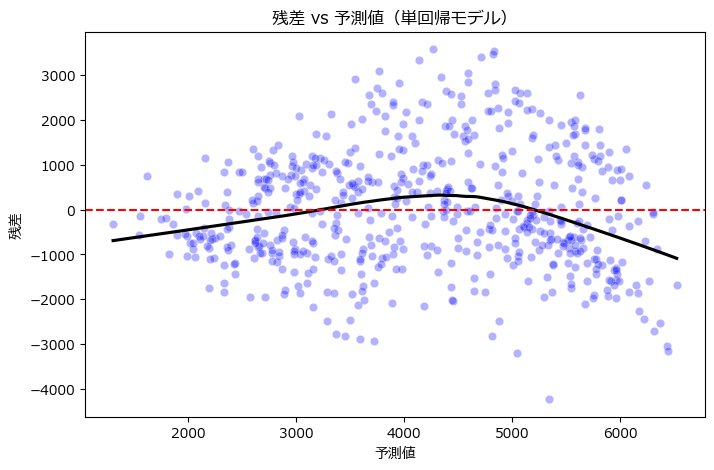

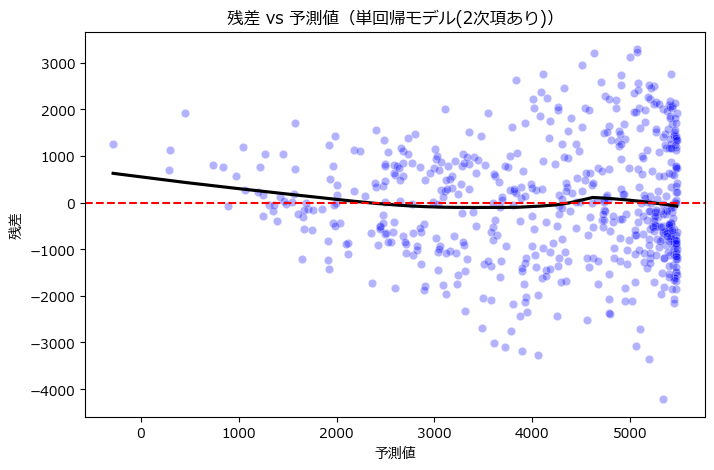

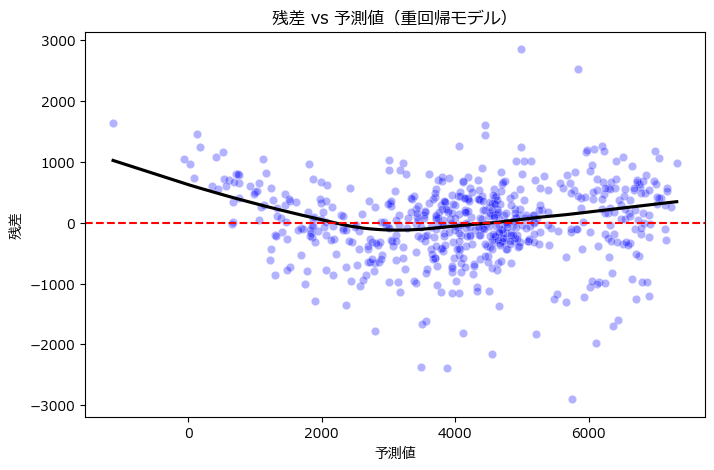

In [15]:
# 残差と予測値を比較する図
models_for_resid = {
    '単回帰モデル': simple_model,
    '単回帰モデル(2次項あり)': simple2_model,
    '重回帰モデル': mul_model
}

resid_and_predict(models_for_resid)

# 8. テストデータでの予測性能評価

In [16]:
evaluate_df = mae_rmse_r2(models=models, test_df=test_df)
evaluate_df

,モデル名,MAE,RMSE,R2
0,nullモデル,2290.413,2560.556,-0.866
1,単回帰モデル,2053.295,2284.494,-0.485
2,単回帰モデル(2次項あり),1948.250,2151.718,-0.317
3,重回帰モデル,777.198,1049.532,0.687


# 9. 残差分析
以下では、テストデータに対して残差と予測値の比較を行う。

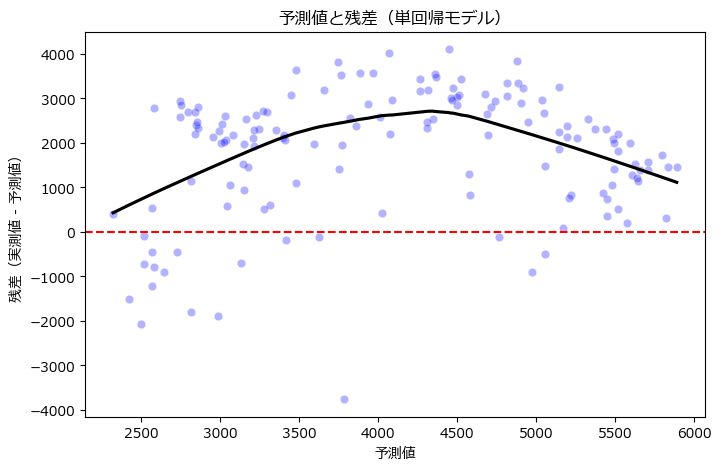

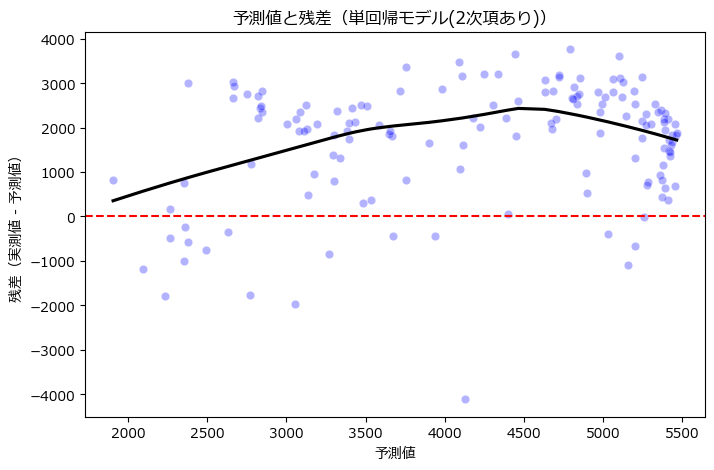

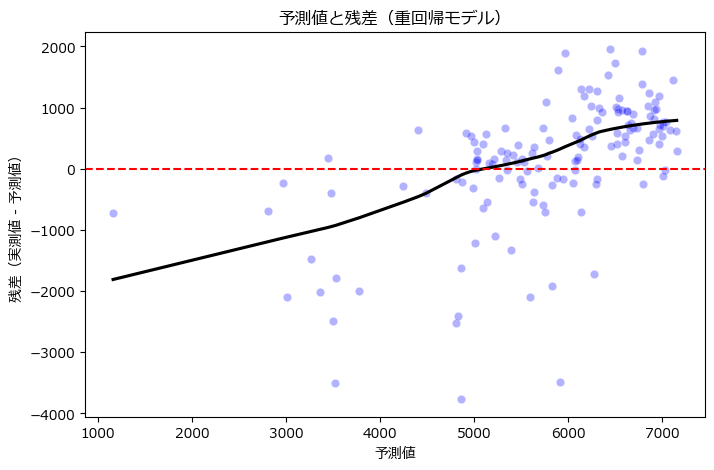

In [17]:
test_pred_resid(models_for_resid, test_df)

# 10. 考察

## 10.1 結果のまとめ

訓練データに対する精度指標のまとめは以下の通りである。

|モデル名|R²|Adj. R²|AIC|BIC|MAE|RMSE|
|---|---:|---:|---:|---:|---:|---:|
|nullモデル|-|-|-|-|1442.951|1787.355|
|単回帰モデル|0.469|0.468|10038.106|10046.846|1057.669|1302.324|
|単回帰モデル(2次項あり)|0.508|0.506|9995.706|10008.816|1012.727|1253.747|
|重回帰モデル|0.876|0.870|9242.432|9364.789|469.673|630.276|

テストデータに対する予測性能は以下の通りである。

|モデル名|MAE|RMSE|R²|
|---|---:|---:|---:|
|nullモデル|2290.413|2560.556|-0.866|
|単回帰モデル|2053.295|2284.494|-0.485|
|単回帰モデル(2次項あり)|1948.250|2151.718|-0.317|
|重回帰モデル|777.198|1049.532|0.687|

AIC・BICは、訓練データに対する当てはまりとモデルの複雑さのバランスを評価する指標である。
一方、テストデータに対するMAE・RMSE・R²は、未知データに対する予測性能を評価する指標である。
そのため、最終的なモデル選択では、訓練データ上の当てはまりだけでなく、テストデータ上の予測性能も重視する。

## 10.2 モデル比較

訓練データでは、説明変数を増やすにつれてR²が上昇し、AIC・BICも低下した。
特に重回帰モデルでは、R²が0.876、自由度調整済みR²が0.870となり、訓練データに対して高い説明力を示した。

一方、テストデータでは、単回帰モデルおよび2次項あり単回帰モデルのR²が負になった。
これは、気温のみでは将来期間の利用者数を十分に予測できず、テストデータの平均値を基準とした予測よりも誤差が大きいことを意味する。

ただし、本分析のnullモデルは訓練データの平均値を用いてテストデータを予測しているため、テストデータ上のR²はnullモデルでも負になっている。

重回帰モデルでは、テストデータに対するMAEが777.198、RMSEが1049.532、R²が0.687となり、他のモデルよりも高い予測性能を示した。
この結果から、Bike Sharingの利用者数は気温だけでなく、湿度、風速、天候、曜日、月、年次といった複数の要因に影響されることが分かる。

したがって、本分析では重回帰モデルを最終モデルとして採用する。

## 10.3 係数の解釈

重回帰モデルの係数を見ると、`temp` は正、`hum` と `windspeed` は負の係数を持っている。
これは、気温が高いほど利用者数が増加しやすい一方で、湿度や風速が高い日は利用者数が減少しやすいことを示唆している。

ただし、`temp` には2次項も含めているため、気温の効果は単純な直線的増加ではなく、一定以上の気温では増加幅が小さくなる、または減少に転じる可能性がある。

特に `yr` や `mnth` は予測性能の改善に大きく寄与していると考えられる。
`yr` は2011年と2012年の水準差を表しており、サービスの認知度向上や利用定着による需要増加を反映している可能性がある。
また、`mnth` は月ごとの季節性を補足しており、気温だけでは説明できない周期的な需要変動を捉えていると考えられる。

ただし、`yr` は2011年と2012年の違いを表すダミー変数であり、2013年以降のような未知の年を予測する場合には、そのまま利用しにくい。
そのため、本モデルは2011年・2012年の範囲内での予測には有効だが、長期的な外挿予測には限界がある。

## 10.4 残差分析と限界

残差分析では、単回帰モデルに比べて重回帰モデルの残差のばらつきは小さくなっている。
一方で、テストデータにおける重回帰モデルの残差には、一定の傾向が残っている。

特に高需要日の利用者数を過小評価している可能性がある。
したがって、重回帰モデルは単回帰モデルより予測性能が高いものの、線形回帰モデルのみでは捉えきれない非線形性や時系列的な構造が残っていると考えられる。

## 10.5 今後の改善

今後の改善としては、祝日や労働日、体感温度などの追加変数を用いること、交互作用項を導入すること、またランダムフォレストや勾配ブースティングなどの非線形モデルと比較することが考えられる。